# Lab 8: Networks for Macroeconomics and Finance

**ECON5129 Statistical Machine Learning** &middot; Adam Smith Business School, University of Glasgow

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/korobilis/ECON5129-labs/blob/main/solutions/lab08_deep_learning_applications_solutions.ipynb)

This lab accompanies Lecture 8. By the end of the session you should be able to:

1. Apply a neural network to a macroeconomic forecasting problem and evaluate it honestly against the benchmarks from Labs 3 and 6.
2. Demonstrate that a single trained network is a random object, and stabilise it by ensembling across seeds.
3. Build a recurrent network with backpropagation through time and say when recurrence beats a fixed lag window.
4. Train an autoencoder as a nonlinear factor model and compare it with the principal components of Lab 4.
5. Estimate a nonlinear asset pricing model on a simulated panel and translate the predictions into a portfolio.
6. Apply the reality checks that separate a real result from a plausible-looking one.

The network built from scratch in Lab 7 is available as `e5.NeuralNetwork`, generalised to multiple outputs. Nothing in this lab requires a deep learning library.

**Plan for the session**

| Time | Part |
|---|---|
| 0:00 - 0:30 | Part 1. Networks for macroeconomic forecasting |
| 0:30 - 0:50 | Part 2. Seeds, ensembles and reality checks |
| 0:50 - 1:15 | Part 3. Recurrent networks |
| 1:15 - 1:35 | Part 4. Autoencoders as nonlinear factor models |
| 1:35 - 2:00 | Part 5. Deep learning for asset pricing |

## Setup

In [1]:
import os
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/korobilis/ECON5129-labs/main"

if not os.path.exists("econ5129_utils.py"):
    urllib.request.urlretrieve(f"{REPO_RAW}/econ5129_utils.py", "econ5129_utils.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import econ5129_utils as e5

e5.set_style()
rng = np.random.default_rng(5129)

## Part 1. Networks for macroeconomic forecasting

The problem is the one that has run through Labs 3, 4 and 6: the monthly change in the US unemployment rate, one month ahead, from three lags of 121 macroeconomic series.

The sample is small by the standards of the deep learning literature. Roughly 500 training observations and 363 predictors is a setting where a large network will memorise the training data unless held back firmly.

In [2]:
data, codes = e5.load_fredmd()
dataset = e5.build_forecast_dataset(data, codes, target="UNRATE", horizon=1, n_lags=3)
X, y, dates = dataset["X"], dataset["y"], dataset["dates"]

split = int(0.7 * len(y))
X_tr, X_te, y_tr, y_te = X[:split], X[split:], y[:split], y[split:]
Z_tr, Z_te, _, _ = e5.standardise(X_tr, X_te)
y_mean, y_sd = y_tr.mean(), y_tr.std()

ar_cols = [i for i, name in enumerate(dataset["names"]) if name.startswith("UNRATE.")]
b_ar, *_ = np.linalg.lstsq(np.column_stack([np.ones(split), X_tr[:, ar_cols]]), y_tr, rcond=None)
bench = np.column_stack([np.ones(len(y_te)), X_te[:, ar_cols]]) @ b_ar

print(f"training {split} months to {dates[split - 1]:%Y-%m}, "
      f"evaluation {len(y_te)} months from {dates[split]:%Y-%m}")

training 501 months to 2001-12, evaluation 216 months from 2002-01


Scaling the target as well as the predictors matters here. Gradient descent with a fixed learning rate behaves very differently on a target with standard deviation 0.17 than on one with standard deviation 17.

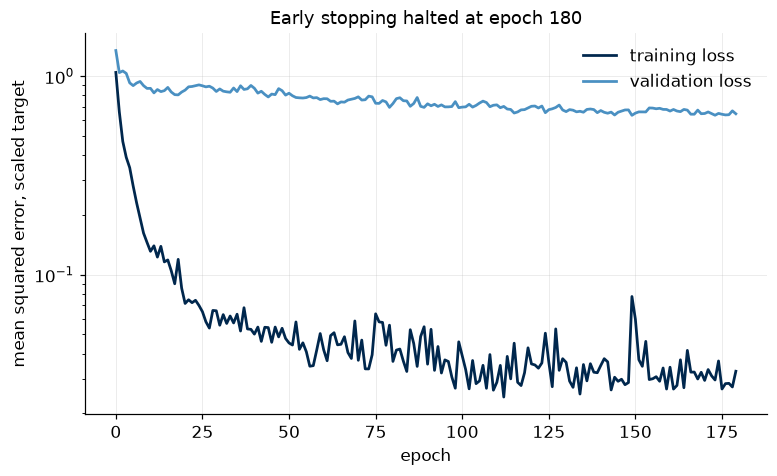

out-of-sample R-squared against the AR benchmark: -0.2137


In [3]:
y_tr_scaled = (y_tr - y_mean) / y_sd

validation_start = int(0.85 * split)
net = e5.NeuralNetwork([Z_tr.shape[1], 32, 16, 1], seed=0, weight_decay=1e-4, dropout=0.1)
history = net.fit(
    Z_tr[:validation_start], y_tr_scaled[:validation_start],
    X_val=Z_tr[validation_start:], y_val=y_tr_scaled[validation_start:],
    n_epochs=300, batch_size=32, learning_rate=0.003, patience=30,
)

pred_net = net.predict(Z_te) * y_sd + y_mean

fig, ax = plt.subplots()
ax.plot(history["train"], label="training loss")
ax.plot(history["validation"], label="validation loss")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("mean squared error, scaled target")
ax.set_title(f"Early stopping halted at epoch {history.get('stopped_at', len(history['train']))}")
ax.legend()
plt.show()

print(f"out-of-sample R-squared against the AR benchmark: "
      f"{e5.oos_r2(y_te, pred_net, benchmark=bench):.4f}")

The number is negative: this network is beaten by an autoregression on three lags of the target. Before reaching for a bigger architecture, note the arithmetic of the problem. Roughly 500 training observations, 363 predictors, and a target whose month-to-month variation is mostly noise. There is not much information here to estimate thousands of weights from.

Resist the urge to tune until the number turns positive. That procedure, repeated across a literature, produces published results that do not replicate. Instead, ask first how much of that number is signal and how much is the random seed.

## Part 2. Seeds, ensembles and reality checks

The number above also came from one random initialisation. Change the seed and the optimiser lands somewhere else on a non-convex surface. Reporting a single run is the most common way to overstate a result in this literature.

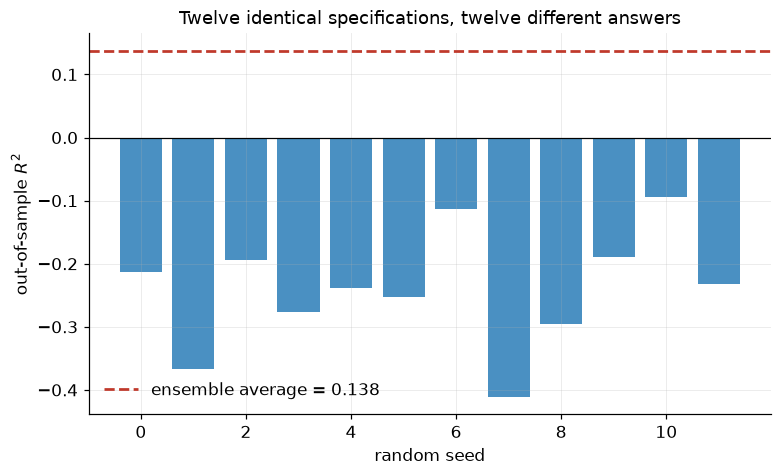

worst seed : -0.4113
best seed  : -0.0938
ensemble   : 0.1379


In [4]:
seed_predictions = []
for seed in range(12):
    net_s = e5.NeuralNetwork([Z_tr.shape[1], 32, 16, 1], seed=seed,
                             weight_decay=1e-4, dropout=0.1)
    net_s.fit(Z_tr[:validation_start], y_tr_scaled[:validation_start],
              X_val=Z_tr[validation_start:], y_val=y_tr_scaled[validation_start:],
              n_epochs=300, batch_size=32, learning_rate=0.003, patience=30)
    seed_predictions.append(net_s.predict(Z_te) * y_sd + y_mean)

seed_predictions = np.array(seed_predictions)
seed_scores = [e5.oos_r2(y_te, p, benchmark=bench) for p in seed_predictions]
ensemble = seed_predictions.mean(axis=0)

fig, ax = plt.subplots()
ax.bar(range(len(seed_scores)), seed_scores, color=e5.COLORS[1])
ax.axhline(e5.oos_r2(y_te, ensemble, benchmark=bench), color=e5.COLORS[2], ls="--",
           label=f"ensemble average = {e5.oos_r2(y_te, ensemble, benchmark=bench):.3f}")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("random seed")
ax.set_ylabel("out-of-sample $R^2$")
ax.set_title("Twelve identical specifications, twelve different answers")
ax.legend()
plt.show()

print(f"worst seed : {min(seed_scores):.4f}")
print(f"best seed  : {max(seed_scores):.4f}")
print(f"ensemble   : {e5.oos_r2(y_te, ensemble, benchmark=bench):.4f}")

The spread across seeds is often as large as the difference between competing methods in published tables. A study that reports one run, or that quietly reports the best of several, is reporting the seed rather than the method.

Averaging the predictions across seeds costs nothing beyond computing time, and here it does something dramatic: every individual network loses to the autoregressive benchmark, and their average beats it. Nothing about the architecture changed. The individual networks were not biased, they were noisy, and averaging removes noise for the same reason bagging works in Lab 6.

This is the single most useful practical fact in the lecture. If you fit one network and report it, you are reporting a draw from a distribution whose spread you have not measured.

### Exercise 1

Place the ensemble in the company of the estimators from earlier labs.

1. Fit the LASSO and a random forest to the same training data.
2. Report out-of-sample $R^2$ against the autoregressive benchmark for the LASSO, the forest, the single network and the ensemble.
3. Test whether the ensemble beats the LASSO using `e5.diebold_mariano`.

Would you report the network result in a paper?

In [5]:
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit

lasso = LassoCV(alphas=np.logspace(-4, 1, 60), cv=TimeSeriesSplit(5),
                max_iter=50000).fit(Z_tr, y_tr - y_mean)
forest = RandomForestRegressor(n_estimators=400, max_features=0.3, min_samples_leaf=5,
                               random_state=0, n_jobs=1).fit(Z_tr, y_tr - y_mean)

pred_lasso = lasso.predict(Z_te) + y_mean
pred_forest = forest.predict(Z_te) + y_mean

print(pd.DataFrame([
    {"model": "LASSO", "out-of-sample $R^2$": e5.oos_r2(y_te, pred_lasso, bench)},
    {"model": "random forest", "out-of-sample $R^2$": e5.oos_r2(y_te, pred_forest, bench)},
    {"model": "network, single seed", "out-of-sample $R^2$": e5.oos_r2(y_te, pred_net, bench)},
    {"model": "network, 12-seed ensemble", "out-of-sample $R^2$": e5.oos_r2(y_te, ensemble, bench)},
]).set_index("model").round(4))

stat, pval = e5.diebold_mariano(y_te - ensemble, y_te - pred_lasso)
print(f"\nDiebold-Mariano, ensemble against LASSO: statistic {stat:.3f}, p-value {pval:.3f}")

                           out-of-sample $R^2$
model                                         
LASSO                                   0.1856
random forest                           0.1914
network, single seed                   -0.2137
network, 12-seed ensemble               0.1379

Diebold-Mariano, ensemble against LASSO: statistic 0.869, p-value 0.386


## Part 3. Recurrent networks

A feedforward network applied to lagged inputs has a fixed memory: whatever you put in the window. A recurrent network carries a hidden state forward,

$$ \mathbf{h}_t = \tanh\left(\mathbf{W}_x x_t + \mathbf{W}_h \mathbf{h}_{t-1} + \mathbf{b}\right), \qquad \widehat{y}_t = \mathbf{w}_y'\mathbf{h}_t + c, $$

so information can persist for an unbounded number of periods. Training uses the same chain rule, unrolled through time, which is why it is called backpropagation through time.

The process below is designed so that memory matters: the response depends on the accumulated level of a shock that decays slowly, and the sign of the effect depends on a regime that switches.

In [6]:
def simulate_memory_process(n_series=300, length=30, seed=0):
    """Sequences whose target depends on a slowly decaying accumulation."""
    gen = np.random.default_rng(seed)
    x = gen.normal(size=(n_series, length))

    state = np.zeros((n_series, length))
    for t in range(1, length):
        state[:, t] = 0.9 * state[:, t - 1] + x[:, t]

    y = np.tanh(state[:, -1]) + 0.1 * gen.normal(size=n_series)
    return x, y


X_seq, y_seq = simulate_memory_process(seed=1)
X_seq_test, y_seq_test = simulate_memory_process(n_series=500, seed=2)


class SimpleRNN:
    """Elman recurrent network trained by backpropagation through time."""

    def __init__(self, n_hidden=8, seed=0):
        gen = np.random.default_rng(seed)
        self.Wx = gen.normal(scale=0.3, size=n_hidden)
        self.Wh = gen.normal(scale=0.3, size=(n_hidden, n_hidden))
        self.b = np.zeros(n_hidden)
        self.wy = gen.normal(scale=0.3, size=n_hidden)
        self.c = 0.0
        self.n_hidden = n_hidden

    def forward(self, X):
        """Run the sequence forward, storing hidden states for the backward pass."""
        n, length = X.shape
        H = np.zeros((n, length + 1, self.n_hidden))
        for t in range(length):
            a = X[:, t][:, None] * self.Wx + H[:, t] @ self.Wh.T + self.b
            H[:, t + 1] = np.tanh(a)
        return H, H[:, -1] @ self.wy + self.c

    def gradients(self, X, y):
        """Backpropagation through time for squared error loss."""
        n, length = X.shape
        H, pred = self.forward(X)
        error = (2.0 / n) * (pred - y)

        g_wy = H[:, -1].T @ error
        g_c = error.sum()

        dh = error[:, None] * self.wy
        g_Wx = np.zeros_like(self.Wx)
        g_Wh = np.zeros_like(self.Wh)
        g_b = np.zeros_like(self.b)

        for t in reversed(range(length)):
            da = dh * (1.0 - H[:, t + 1] ** 2)
            g_Wx += (da * X[:, t][:, None]).sum(axis=0)
            g_Wh += da.T @ H[:, t]
            g_b += da.sum(axis=0)
            dh = da @ self.Wh
        return g_Wx, g_Wh, g_b, g_wy, g_c

    def fit(self, X, y, n_epochs=300, learning_rate=0.02):
        losses = []
        for _ in range(n_epochs):
            g_Wx, g_Wh, g_b, g_wy, g_c = self.gradients(X, y)
            self.Wx -= learning_rate * g_Wx
            self.Wh -= learning_rate * g_Wh
            self.b -= learning_rate * g_b
            self.wy -= learning_rate * g_wy
            self.c -= learning_rate * g_c
            losses.append(e5.mse(y, self.forward(X)[1]))
        return np.array(losses)

    def predict(self, X):
        return self.forward(X)[1]


rnn = SimpleRNN(n_hidden=8, seed=3)
rnn_losses = rnn.fit(X_seq, y_seq, n_epochs=400, learning_rate=0.05)

The comparison is against a feedforward network given the last five observations of each sequence, which is the standard way an econometrician would set the problem up.

                          test MSE
model                             
recurrent network           0.1024
feedforward, last 5 lags    0.6266
feedforward, all 30 lags    0.1582
predict the mean            0.6998


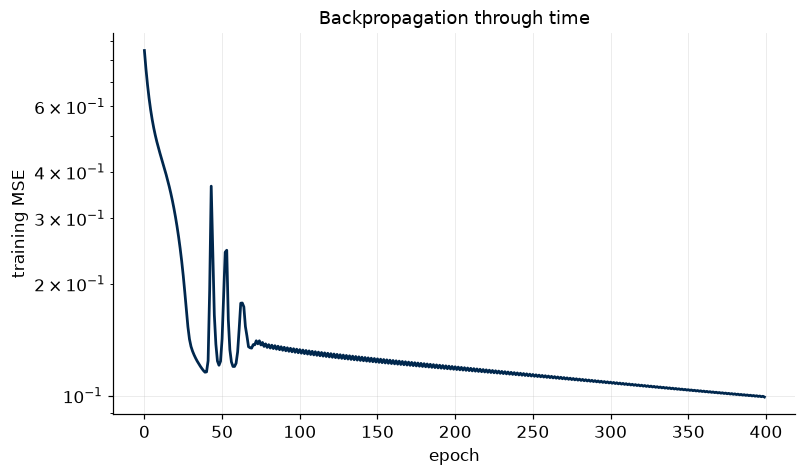

In [7]:
window = 5
mlp_seq = e5.NeuralNetwork([window, 16, 8, 1], seed=3)
mlp_seq.fit(X_seq[:, -window:], y_seq, n_epochs=400, batch_size=32, learning_rate=0.01)

full_mlp = e5.NeuralNetwork([X_seq.shape[1], 16, 8, 1], seed=3)
full_mlp.fit(X_seq, y_seq, n_epochs=400, batch_size=32, learning_rate=0.01)

print(pd.DataFrame([
    {"model": "recurrent network", "test MSE": e5.mse(y_seq_test, rnn.predict(X_seq_test))},
    {"model": f"feedforward, last {window} lags",
     "test MSE": e5.mse(y_seq_test, mlp_seq.predict(X_seq_test[:, -window:]))},
    {"model": "feedforward, all 30 lags",
     "test MSE": e5.mse(y_seq_test, full_mlp.predict(X_seq_test))},
    {"model": "predict the mean", "test MSE": e5.mse(y_seq_test, np.full_like(y_seq_test, y_seq.mean()))},
]).set_index("model").round(4))

fig, ax = plt.subplots()
ax.plot(rnn_losses)
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("training MSE")
ax.set_title("Backpropagation through time")
plt.show()

### Exercise 2

Recurrence is only worth its cost when the memory required is long.

1. Modify `simulate_memory_process` so the decay coefficient is 0.3 rather than 0.9, making the process nearly memoryless.
2. Refit all three models.
3. Compare the ranking with the one above.

State the condition under which the recurrent architecture earns its complexity.

In [8]:
def simulate_with_decay(decay, n_series=300, length=30, seed=0):
    """Sequence process with a tunable persistence parameter."""
    gen = np.random.default_rng(seed)
    x = gen.normal(size=(n_series, length))
    state = np.zeros((n_series, length))
    for t in range(1, length):
        state[:, t] = decay * state[:, t - 1] + x[:, t]
    return x, np.tanh(state[:, -1]) + 0.1 * gen.normal(size=n_series)


rows = []
for decay in [0.9, 0.3]:
    Xd, yd = simulate_with_decay(decay, seed=1)
    Xd_te, yd_te = simulate_with_decay(decay, n_series=500, seed=2)

    r = SimpleRNN(n_hidden=8, seed=3)
    r.fit(Xd, yd, n_epochs=400, learning_rate=0.05)

    m = e5.NeuralNetwork([window, 16, 8, 1], seed=3)
    m.fit(Xd[:, -window:], yd, n_epochs=400, batch_size=32, learning_rate=0.01)

    rows.append({
        "decay": decay,
        "recurrent": e5.mse(yd_te, r.predict(Xd_te)),
        f"feedforward, {window} lags": e5.mse(yd_te, m.predict(Xd_te[:, -window:])),
    })

print(pd.DataFrame(rows).set_index("decay").round(4))

       recurrent  feedforward, 5 lags
decay                                
0.9       0.1024               0.6266
0.3       0.0144               0.0258


## Part 4. Autoencoders as nonlinear factor models

An autoencoder compresses the data through a bottleneck and reconstructs it,

$$ \mathbf{x} \; \longrightarrow \; \mathbf{f} = g(\mathbf{x}) \; \longrightarrow \; \widehat{\mathbf{x}} = h(\mathbf{f}), $$

minimising reconstruction error. If $g$ and $h$ are linear this recovers the principal component subspace exactly, which is the cleanest statement of the connection to Lecture 4. Making them nonlinear gives a factor model in which the loadings can bend.

In [9]:
transformed = e5.fredmd_transform(data, codes).loc["1960-01":"2019-12"]
panel = transformed.loc[:, transformed.notna().all(axis=0)]
P = ((panel - panel.mean()) / panel.std()).to_numpy()

T_obs, N_series = P.shape
train_end = int(0.7 * T_obs)
P_tr, P_te = P[:train_end], P[train_end:]

q = 8
U, d, Vt = np.linalg.svd(P_tr, full_matrices=False)
pca_reconstruction = (P_te @ Vt[:q].T) @ Vt[:q]
pca_error = e5.mse(P_te, pca_reconstruction)

auto = e5.NeuralNetwork([N_series, 32, q, 32, N_series], seed=1, weight_decay=1e-5)
auto.fit(P_tr, P_tr, n_epochs=400, batch_size=32, learning_rate=0.003)
auto_error = e5.mse(P_te, auto.predict(P_te))

print(f"out-of-sample reconstruction error, {q} principal components : {pca_error:.4f}")
print(f"out-of-sample reconstruction error, autoencoder bottleneck {q}: {auto_error:.4f}")

out-of-sample reconstruction error, 8 principal components : 0.6622
out-of-sample reconstruction error, autoencoder bottleneck 8: 1.3322


### Exercise 3

Does the nonlinear factor structure buy anything for forecasting, or only for reconstruction?

1. Extract the bottleneck representation of the panel by running the encoder half of the network.
2. Use those eight nonlinear factors, lagged once, as predictors of the change in unemployment, and compare with the eight principal components used the same way.
3. Report out-of-sample $R^2$ for both, measured against a forecast of the training-sample mean.

In [10]:
def encode(net, X, bottleneck_layer=2):
    """Run the input through the first layers of the autoencoder."""
    A = X
    for layer in range(bottleneck_layer):
        A = A @ net.W[layer] + net.b[layer]
        if layer < bottleneck_layer - 1:
            A = np.maximum(A, 0.0)
    return A


factors_nonlinear = encode(auto, P)
factors_linear = P @ Vt[:q].T

target = panel["UNRATE"].to_numpy()

rows = []
for name, F in [("principal components", factors_linear), ("autoencoder factors", factors_nonlinear)]:
    F_lag, target_next = F[:-1], target[1:]
    s = int(0.7 * len(target_next))

    Ztr, Zte, _, _ = e5.standardise(F_lag[:s], F_lag[s:])
    coef, *_ = np.linalg.lstsq(np.column_stack([np.ones(s), Ztr]), target_next[:s], rcond=None)
    pred = np.column_stack([np.ones(len(Zte)), Zte]) @ coef

    ar_bench = np.full(len(target_next) - s, target_next[:s].mean())
    rows.append({"predictors": name,
                 "out-of-sample $R^2$": e5.oos_r2(target_next[s:], pred, benchmark=ar_bench)})

print(pd.DataFrame(rows).set_index("predictors").round(4))

                      out-of-sample $R^2$
predictors                               
principal components               0.0494
autoencoder factors                0.1551


## Part 5. Deep learning for asset pricing

The empirical asset pricing literature asks whether expected returns depend nonlinearly on firm characteristics. The simulated panel below is built so that the answer is yes: expected returns depend on the square of momentum and on an interaction between size and value, neither of which a linear model can represent.

The noise is deliberately large, as it is in real return data.

In [11]:
characteristics, returns, expected = e5.simulate_asset_panel(n_stocks=200, n_periods=240, seed=2)
n_periods, n_stocks, n_chars = characteristics.shape

split_t = 168
X_panel = characteristics.reshape(-1, n_chars)
y_panel = returns.reshape(-1)
period_index = np.repeat(np.arange(n_periods), n_stocks)

train_mask = period_index < split_t
Xp_tr, Xp_te = X_panel[train_mask], X_panel[~train_mask]
yp_tr, yp_te = y_panel[train_mask], y_panel[~train_mask]

linear_coef, *_ = np.linalg.lstsq(
    np.column_stack([np.ones(len(Xp_tr)), Xp_tr]), yp_tr, rcond=None)
pred_linear = np.column_stack([np.ones(len(Xp_te)), Xp_te]) @ linear_coef

net_ap = e5.NeuralNetwork([n_chars, 32, 16, 1], seed=0, weight_decay=1e-4)
net_ap.fit(Xp_tr, yp_tr, n_epochs=60, batch_size=256, learning_rate=0.01)
pred_ap = net_ap.predict(Xp_te)

print(pd.DataFrame([
    {"model": "linear", "out-of-sample $R^2$": e5.oos_r2(yp_te, pred_linear)},
    {"model": "neural network", "out-of-sample $R^2$": e5.oos_r2(yp_te, pred_ap)},
]).set_index("model").round(4))

                out-of-sample $R^2$
model                              
linear                       0.0072
neural network               0.1401


An out-of-sample $R^2$ of a percent or two is what the literature reports for monthly returns, and it is not a disappointment. The economically meaningful question is whether the predictions sort stocks into portfolios that differ in realised return.

                mean return  monthly Sharpe
strategy                                   
linear               0.5652          1.1513
neural network       2.0426          4.9087


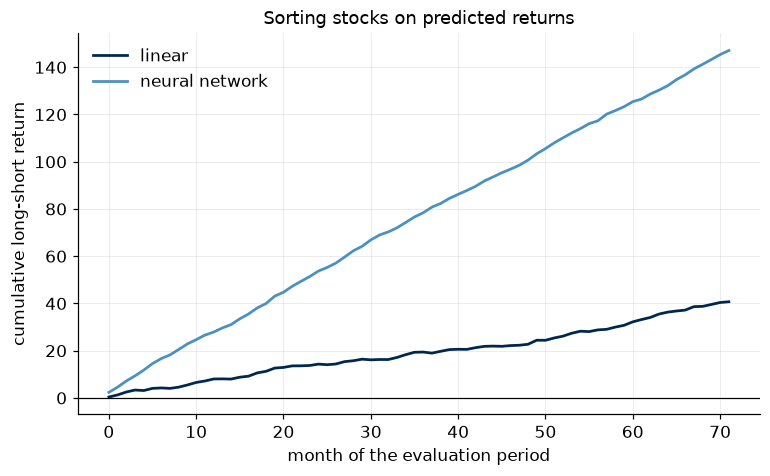

In [12]:
def long_short_returns(predictions, actual, periods, n_groups=5):
    """Return the top-minus-bottom quintile portfolio return in each period."""
    out = []
    for t in np.unique(periods):
        mask = periods == t
        p, r = predictions[mask], actual[mask]
        order = np.argsort(p)
        k = len(order) // n_groups
        out.append(r[order[-k:]].mean() - r[order[:k]].mean())
    return np.array(out)


test_periods = period_index[~train_mask]
ls_linear = long_short_returns(pred_linear, yp_te, test_periods)
ls_net = long_short_returns(pred_ap, yp_te, test_periods)

print(pd.DataFrame([
    {"strategy": "linear", "mean return": ls_linear.mean(),
     "monthly Sharpe": ls_linear.mean() / ls_linear.std()},
    {"strategy": "neural network", "mean return": ls_net.mean(),
     "monthly Sharpe": ls_net.mean() / ls_net.std()},
]).set_index("strategy").round(4))

fig, ax = plt.subplots()
ax.plot(np.cumsum(ls_linear), label="linear")
ax.plot(np.cumsum(ls_net), label="neural network")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("month of the evaluation period")
ax.set_ylabel("cumulative long-short return")
ax.set_title("Sorting stocks on predicted returns")
ax.legend()
plt.show()

### Exercise 4

Recover the nonlinearity the network found and check it against the truth.

1. Compute the partial dependence of the fitted network on momentum: vary momentum over a grid, hold the other characteristics at zero, and record the prediction.
2. Overlay the true function, which is $0.5 \times \text{momentum}^2$.
3. Do the same for size, whose true effect is zero except through its interaction with value.

What would a linear model have reported for the momentum effect, and why is that answer both wrong and unsurprising?

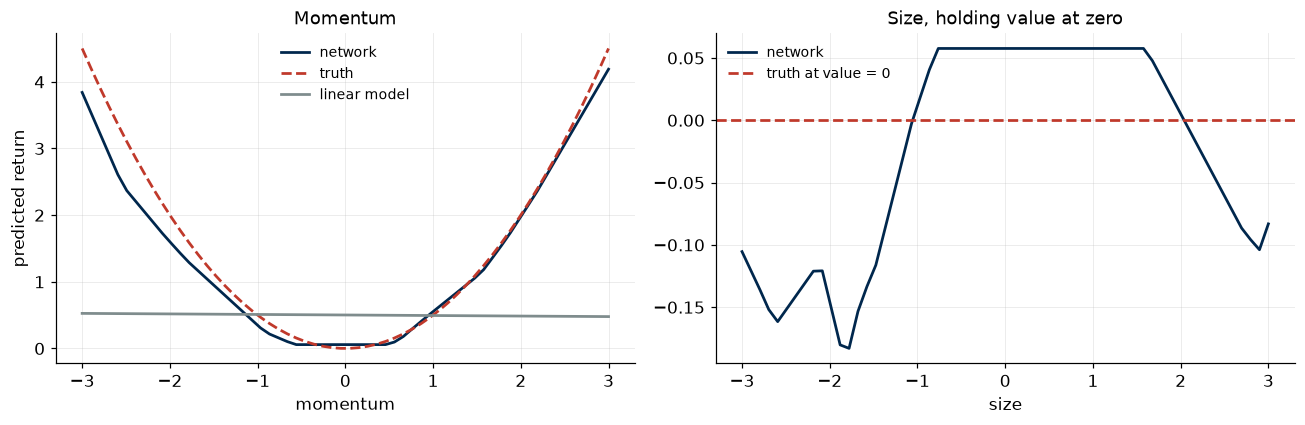

In [13]:
mom_grid = np.linspace(-3, 3, 60)
probe = np.zeros((len(mom_grid), n_chars))
probe[:, 2] = mom_grid

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(mom_grid, net_ap.predict(probe), color=e5.COLORS[0], label="network")
axes[0].plot(mom_grid, 0.5 * mom_grid ** 2, color=e5.COLORS[2], ls="--", label="truth")
axes[0].plot(mom_grid, linear_coef[0] + linear_coef[3] * mom_grid,
             color=e5.COLORS[6], label="linear model")
axes[0].set_xlabel("momentum")
axes[0].set_ylabel("predicted return")
axes[0].set_title("Momentum")
axes[0].legend(fontsize=9)

size_grid = np.linspace(-3, 3, 60)
probe_size = np.zeros((len(size_grid), n_chars))
probe_size[:, 0] = size_grid
axes[1].plot(size_grid, net_ap.predict(probe_size), color=e5.COLORS[0], label="network")
axes[1].axhline(0, color=e5.COLORS[2], ls="--", label="truth at value = 0")
axes[1].set_xlabel("size")
axes[1].set_title("Size, holding value at zero")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

## Take-home challenges

1. **Expanding window evaluation.** Replace the single split in Part 1 with an expanding window that refits the ensemble every twelve months using `e5.expanding_window_splits`. Report the out-of-sample $R^2$ over the full evaluation period. Does the advantage survive?

2. **How much data does a network need?** Repeat Part 1 with training samples of 100, 200, 300 and 500 months, and plot performance against sample size for the network and for the LASSO. At what sample size do the lines cross, if they do?

3. **Architecture search done honestly.** Try nine architectures crossing widths $\{8, 32, 128\}$ with depths $\{1, 2, 3\}$, selecting by validation loss within the training sample only. Then report the test performance of the winner. Compare with the best test performance across all nine, and explain why the gap between those two numbers is the size of the lie in a badly run study.

4. **Real asset pricing data.** Download the Fama-French 25 portfolios sorted on size and book-to-market together with the factor returns, and repeat Part 5. The characteristics are the portfolio identities themselves, so think carefully about what the network can and cannot learn from 25 assets.

---

**Next**: Lectures 9 and 10 turn to text. Lab 9 converts FOMC transcripts into numbers and measures the tone of monetary policy discussion.